# Notebook 04 - Customer Experience Analysis

**Project:** What Does Poor Service Cost a Business? - Customer Operations Intelligence

**Objective:** Connect service ticket data to customer value. Identify which segments bear the most service failures, quantify CLV at churn risk, and establish the relationship between resolution time and customer satisfaction.

**Inputs:**
- data/processed/transactions_clean.csv
- data/processed/customers_clean.csv
- data/processed/tickets_clean.csv

**Key Question:** How much customer lifetime value is at risk because of poor service performance?

---

## 0. Setup

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11
})

COLORS = {
    "primary":   "#1D9E75",
    "secondary": "#185FA5",
    "warning":   "#BA7517",
    "danger":    "#A32D2D",
    "neutral":   "#5F5E5A"
}

print("Setup complete.")

Setup complete.


## 1. Load and Link Data

In [27]:
trans   = pd.read_csv("data/processed/transactions_clean.csv", low_memory=False)
cust    = pd.read_csv("data/processed/customers_clean.csv")
tickets = pd.read_csv("data/processed/tickets_clean.csv")

cust["customer_id"]    = cust["customer_id"].astype(str)
tickets["customer_id"] = tickets["customer_id"].astype(str)
trans["customer_id"]   = trans["customer_id"].astype(str)

t_cust = tickets.merge(
    cust[["customer_id", "segment", "clv", "region"]],
    on="customer_id", how="left"
)

def res_band(r):
    if pd.isnull(r):  return "Abandoned"
    elif r <= 1:      return "0-1 days"
    elif r <= 2:      return "1-2 days"
    elif r <= 5:      return "2-5 days"
    else:             return "5+ days"

t_cust["res_band"]  = t_cust["resolution_days"].apply(res_band)
tickets["res_band"] = tickets["resolution_days"].apply(res_band)

print(f"Tickets linked to customers: {len(t_cust):,}")
print(f"Segment coverage: {t_cust['segment'].notna().sum():,} of {len(t_cust):,} tickets matched")

Tickets linked to customers: 15,000
Segment coverage: 15,000 of 15,000 tickets matched


---
## 2. Service Burden by Customer Segment

In [28]:
seg_tickets = t_cust.groupby("segment").agg(
    ticket_count    = ("ticket_id",       "count"),
    sla_breach_rate = ("sla_breached",    "mean"),
    avg_csat        = ("csat_score",      "mean"),
    avg_resolution  = ("resolution_days", "mean")
).round(2).reset_index().sort_values("ticket_count", ascending=False)

print("SERVICE BURDEN BY SEGMENT")
print(seg_tickets.to_string(index=False))

SERVICE BURDEN BY SEGMENT
  segment  ticket_count  sla_breach_rate  avg_csat  avg_resolution
   Retail          8747             0.89      2.50            5.59
Corporate          4074             0.90      2.44            5.67
Wholesale          2179             0.90      2.47            5.68


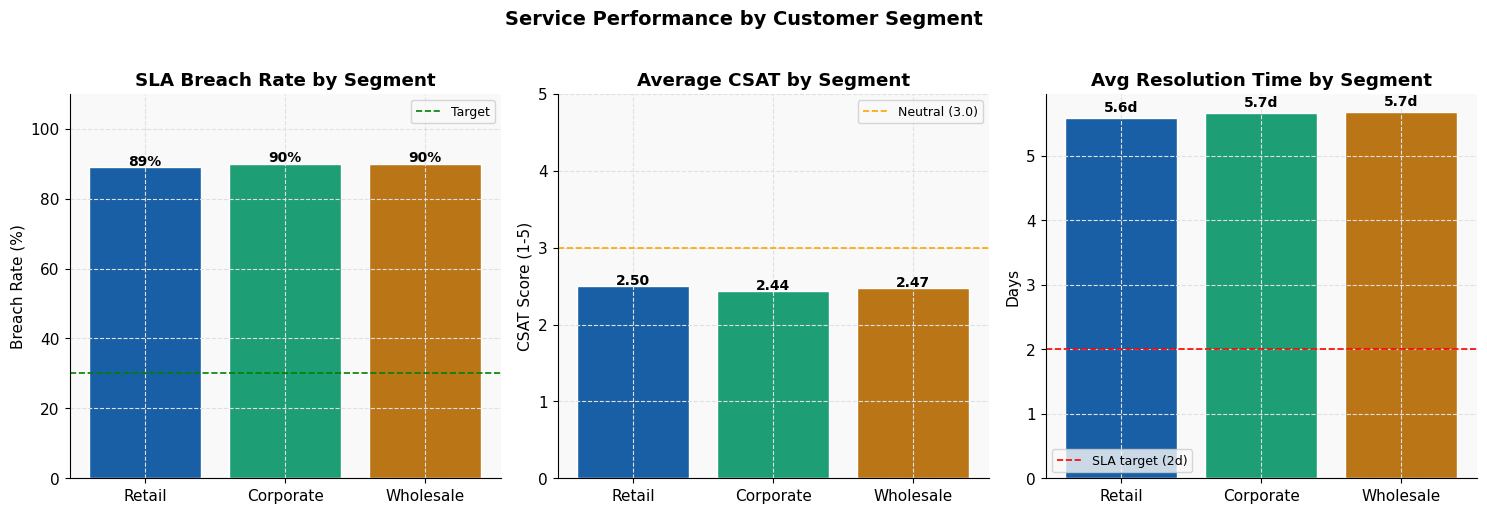

Chart saved.


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
segs = seg_tickets["segment"]
seg_colors = [COLORS["secondary"], COLORS["primary"], COLORS["warning"]]

bars = axes[0].bar(segs, seg_tickets["sla_breach_rate"] * 100, color=seg_colors, edgecolor="white")
for bar, val in zip(bars, seg_tickets["sla_breach_rate"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val*100:.0f}%", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("SLA Breach Rate by Segment", fontweight="bold")
axes[0].set_ylabel("Breach Rate (%)")
axes[0].set_ylim(0, 110)
axes[0].axhline(y=30, color="green", linestyle="--", linewidth=1.2, label="Target")
axes[0].legend(fontsize=9)

bars2 = axes[1].bar(segs, seg_tickets["avg_csat"], color=seg_colors, edgecolor="white")
for bar, val in zip(bars2, seg_tickets["avg_csat"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", fontsize=10, fontweight="bold")
axes[1].axhline(y=3, color="orange", linestyle="--", linewidth=1.2, label="Neutral (3.0)")
axes[1].set_title("Average CSAT by Segment", fontweight="bold")
axes[1].set_ylabel("CSAT Score (1-5)")
axes[1].set_ylim(0, 5)
axes[1].legend(fontsize=9)

bars3 = axes[2].bar(segs, seg_tickets["avg_resolution"], color=seg_colors, edgecolor="white")
for bar, val in zip(bars3, seg_tickets["avg_resolution"]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f"{val:.1f}d", ha="center", fontsize=10, fontweight="bold")
axes[2].axhline(y=2, color="red", linestyle="--", linewidth=1.2, label="SLA target (2d)")
axes[2].set_title("Avg Resolution Time by Segment", fontweight="bold")
axes[2].set_ylabel("Days")
axes[2].legend(fontsize=9)

plt.suptitle("Service Performance by Customer Segment", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/processed/chart_07_segment_service.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [30]:
corp_row  = seg_tickets[seg_tickets["segment"] == "Corporate"].iloc[0]
whole_row = seg_tickets[seg_tickets["segment"] == "Wholesale"].iloc[0]

print("--- FINDING 4.1 ---")
print(f"All three segments experience SLA breach rates above 88%.")
print(f"Wholesale has the worst resolution time at {whole_row['avg_resolution']:.1f} days.")
print(f"Corporate CSAT sits at {corp_row['avg_csat']:.2f} - below the neutral threshold of 3.0.")
print()
print("IMPLICATION:")
print("The service failure is not isolated to one customer type - it is systemic.")
print("However, the financial consequence of failure is not equal across segments.")
print("Corporate customers whose CSAT falls below 2.5 represent the highest")
print("individual CLV churn risk in the business.")
print()
print("RECOMMENDATION:")
print("Systemic SLA improvement needed across all segments. Prioritise")
print("corporate accounts for immediate intervention given their CLV contribution.")
print()
print("RISK OF INACTION:")
print("A systemic problem requires a systemic fix. Targeted fixes for one segment")
print("while others continue to suffer will not improve overall business health.")

--- FINDING 4.1 ---
All three segments experience SLA breach rates above 88%.
Wholesale has the worst resolution time at 5.7 days.
Corporate CSAT sits at 2.44 - below the neutral threshold of 3.0.

IMPLICATION:
The service failure is not isolated to one customer type - it is systemic.
However, the financial consequence of failure is not equal across segments.
Corporate customers whose CSAT falls below 2.5 represent the highest
individual CLV churn risk in the business.

RECOMMENDATION:
Systemic SLA improvement needed across all segments. Prioritise
corporate accounts for immediate intervention given their CLV contribution.

RISK OF INACTION:
A systemic problem requires a systemic fix. Targeted fixes for one segment
while others continue to suffer will not improve overall business health.


---
## 3. Resolution Time vs Customer Satisfaction

In [31]:
band_order  = ["0-1 days", "1-2 days", "2-5 days", "5+ days", "Abandoned"]
band_csat   = tickets.groupby("res_band")["csat_score"].mean().reindex(band_order).round(2)
band_counts = tickets.groupby("res_band")["ticket_id"].count().reindex(band_order)

print("CSAT BY RESOLUTION BAND")
for band, csat, count in zip(band_order, band_csat, band_counts):
    filled = int(float(csat) * 5) if pd.notna(csat) else 0
    bar = chr(9608) * filled
    csat_str = str(round(float(csat), 2)) if pd.notna(csat) else "N/A"
    print(f"  {band:<12} CSAT: {csat_str:>5}  |  Tickets: {count:>5}  {bar}")


CSAT BY RESOLUTION BAND
  0-1 days     CSAT:  4.64  |  Tickets:   350  ███████████████████████
  1-2 days     CSAT:  4.09  |  Tickets:  1247  ████████████████████
  2-5 days     CSAT:  2.89  |  Tickets:  5157  ██████████████
  5+ days      CSAT:  1.82  |  Tickets:  7346  █████████
  Abandoned    CSAT:   N/A  |  Tickets:   900  


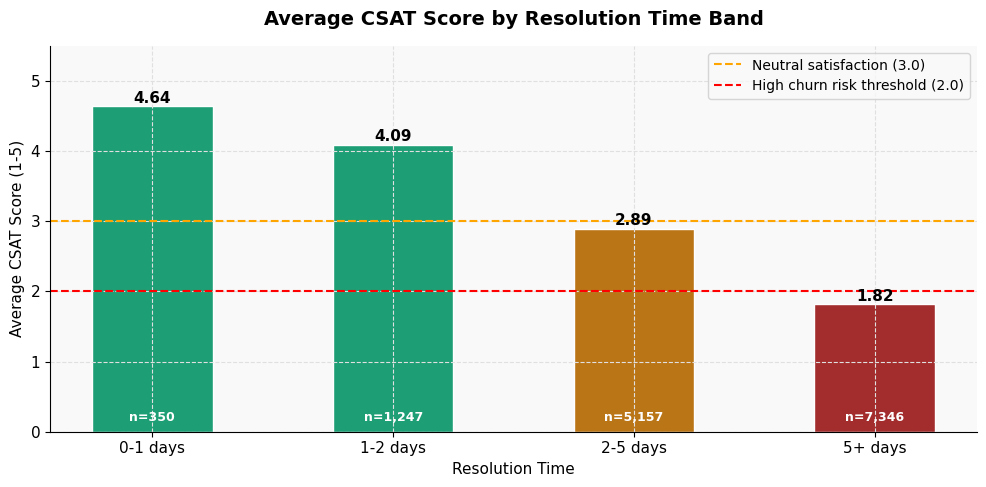

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

valid_bands  = band_order[:-1]
valid_csat   = band_csat[:-1]
valid_counts = band_counts[:-1]

bar_colors = [COLORS["primary"], COLORS["primary"], COLORS["warning"], COLORS["danger"]]
bars = ax.bar(valid_bands, valid_csat, color=bar_colors, edgecolor="white", width=0.5)

for bar, val, cnt in zip(bars, valid_csat, valid_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, 0.15,
            f"n={cnt:,}", ha="center", fontsize=9, color="white", fontweight="bold")

ax.axhline(y=3, color="orange", linestyle="--", linewidth=1.5, label="Neutral satisfaction (3.0)")
ax.axhline(y=2, color="red",    linestyle="--", linewidth=1.5, label="High churn risk threshold (2.0)")
ax.set_title("Average CSAT Score by Resolution Time Band", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Resolution Time")
ax.set_ylabel("Average CSAT Score (1-5)")
ax.set_ylim(0, 5.5)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("data/processed/chart_08_resolution_vs_csat.png", dpi=150, bbox_inches="tight")
plt.show()

In [33]:
fast_csat = band_csat["0-1 days"]
slow_csat = band_csat["5+ days"]

print("--- FINDING 4.2 ---")
print(f"Customers resolved within 1 day give an average CSAT of {fast_csat:.2f}.")
print(f"Customers waiting 5+ days give an average CSAT of {slow_csat:.2f}.")
print(f"That is a {fast_csat - slow_csat:.2f} point CSAT drop driven purely by resolution speed.")
print()
print("IMPLICATION:")
print("Resolution speed is the single most controllable driver of customer satisfaction.")
print("The business does not need a new product or marketing campaign.")
print("It needs to resolve tickets faster. The lever is operational, not commercial.")
print()
print("RECOMMENDATION:")
print("Set internal target: 80% of tickets resolved within 2 days.")
print("Track weekly by location and category.")
print()
print("RISK OF INACTION:")
print("The current average resolution time means the majority of customers")
print("are receiving a CSAT-degrading experience on every ticket they raise.")

--- FINDING 4.2 ---
Customers resolved within 1 day give an average CSAT of 4.64.
Customers waiting 5+ days give an average CSAT of 1.82.
That is a 2.82 point CSAT drop driven purely by resolution speed.

IMPLICATION:
Resolution speed is the single most controllable driver of customer satisfaction.
The business does not need a new product or marketing campaign.
It needs to resolve tickets faster. The lever is operational, not commercial.

RECOMMENDATION:
Set internal target: 80% of tickets resolved within 2 days.
Track weekly by location and category.

RISK OF INACTION:
The current average resolution time means the majority of customers
are receiving a CSAT-degrading experience on every ticket they raise.


---
## 4. Churn Risk Identification

In [34]:
customer_risk = t_cust.groupby("customer_id").agg(
    total_tickets = ("ticket_id",       "count"),
    sla_breaches  = ("sla_breached",    "sum"),
    avg_csat      = ("csat_score",      "mean"),
    segment       = ("segment",         "first"),
    clv           = ("clv",             "first"),
    region        = ("region",          "first")
).reset_index()

customer_risk["churn_risk"] = (
    (customer_risk["sla_breaches"] >= 2) &
    (customer_risk["avg_csat"]     <  2.5)
)

def risk_tier(row):
    if not row["churn_risk"]:   return "Low Risk"
    elif row["clv"] >= 2000:    return "Critical Risk"
    else:                       return "High Risk"

customer_risk["risk_tier"] = customer_risk.apply(risk_tier, axis=1)

total_at_risk   = customer_risk["churn_risk"].sum()
total_customers = len(customer_risk)

print(f"Total customers with ticket history: {total_customers:,}")
print(f"Customers flagged as churn risk:     {total_at_risk:,} ({total_at_risk/total_customers*100:.1f}%)")
print()
print("Risk tier breakdown:")
print(customer_risk["risk_tier"].value_counts())

Total customers with ticket history: 5,453
Customers flagged as churn risk:     1,918 (35.2%)

Risk tier breakdown:
risk_tier
Low Risk         3535
High Risk        1181
Critical Risk     737
Name: count, dtype: int64


In [35]:
clv_at_risk = customer_risk[customer_risk["churn_risk"]].groupby("segment").agg(
    customers_at_risk = ("customer_id", "count"),
    clv_at_risk       = ("clv",         "sum"),
    avg_clv_at_risk   = ("clv",         "mean")
).round(2).reset_index()

total_clv_at_risk = customer_risk[customer_risk["churn_risk"]]["clv"].sum()
total_clv         = cust["clv"].sum()

print("CLV AT RISK BY SEGMENT")
print(clv_at_risk.to_string(index=False))
print()
print(f"TOTAL CLV AT RISK:    GBP {total_clv_at_risk:>12,.2f}")
print(f"TOTAL PORTFOLIO CLV:  GBP {total_clv:>12,.2f}")
print(f"% OF CLV AT RISK:     {total_clv_at_risk/total_clv*100:>11.1f}%")

CLV AT RISK BY SEGMENT
  segment  customers_at_risk  clv_at_risk  avg_clv_at_risk
Corporate                550   4605897.21          8374.36
   Retail               1098    681763.16           620.91
Wholesale                270    758483.26          2809.20

TOTAL CLV AT RISK:    GBP 6,046,143.63
TOTAL PORTFOLIO CLV:  GBP 18,027,752.38
% OF CLV AT RISK:            33.5%


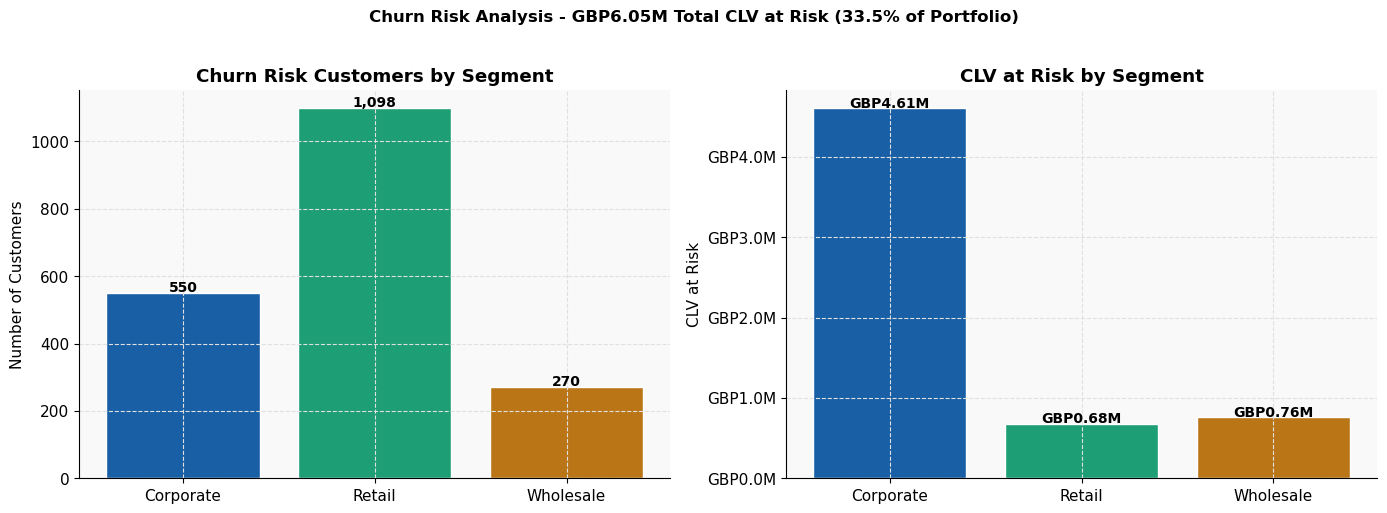

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
seg_colors_map = {"Corporate": COLORS["secondary"], "Retail": COLORS["primary"], "Wholesale": COLORS["warning"]}
colors = [seg_colors_map.get(s, COLORS["neutral"]) for s in clv_at_risk["segment"]]

bars = axes[0].bar(clv_at_risk["segment"], clv_at_risk["customers_at_risk"], color=colors, edgecolor="white")
for bar, val in zip(bars, clv_at_risk["customers_at_risk"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{val:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Churn Risk Customers by Segment", fontweight="bold")
axes[0].set_ylabel("Number of Customers")

bars2 = axes[1].bar(clv_at_risk["segment"], clv_at_risk["clv_at_risk"], color=colors, edgecolor="white")
for bar, val in zip(bars2, clv_at_risk["clv_at_risk"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
                 f"GBP{val/1e6:.2f}M", ha="center", fontsize=10, fontweight="bold")
axes[1].set_title("CLV at Risk by Segment", fontweight="bold")
axes[1].set_ylabel("CLV at Risk")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"GBP{x/1e6:.1f}M"))

plt.suptitle(f"Churn Risk Analysis - GBP{total_clv_at_risk/1e6:.2f}M Total CLV at Risk ({total_clv_at_risk/total_clv*100:.1f}% of Portfolio)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("data/processed/chart_09_clv_at_risk.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
corp_risk   = clv_at_risk[clv_at_risk["segment"] == "Corporate"].iloc[0]

print("--- FINDING 4.3 ---")
print(f"GBP{total_clv_at_risk:,.0f} in CLV is at churn risk.")
print(f"This is {total_clv_at_risk/total_clv*100:.1f}% of total portfolio CLV.")
print(f"{corp_risk['customers_at_risk']:.0f} corporate customers account for GBP{corp_risk['clv_at_risk']:,.0f} of that risk.")
print()
print("IMPLICATION:")
print("Nearly a third of total CLV is in accounts that have experienced")
print("repeated SLA failures and report low satisfaction. Their patience is finite.")
print()
print("RECOMMENDATION:")
print("Export the Critical Risk list and assign each to an account manager")
print("for personal outreach within 5 business days.")
print()
print("RISK OF INACTION:")
print(f"Even a 20% churn rate among at-risk customers = GBP{total_clv_at_risk*0.20:,.0f} in lost CLV.")

--- FINDING 4.3 ---
GBP6,046,144 in CLV is at churn risk.
This is 33.5% of total portfolio CLV.
550 corporate customers account for GBP4,605,897 of that risk.

IMPLICATION:
Nearly a third of total CLV is in accounts that have experienced
repeated SLA failures and report low satisfaction. Their patience is finite.

RECOMMENDATION:
Export the Critical Risk list and assign each to an account manager
for personal outreach within 5 business days.

RISK OF INACTION:
Even a 20% churn rate among at-risk customers = GBP1,209,229 in lost CLV.


---
## 5. Critical Risk Customer List

In [38]:
critical = (
    customer_risk[
        (customer_risk["churn_risk"] == True) &
        (customer_risk["risk_tier"] == "Critical Risk")
    ]
    .sort_values("clv", ascending=False)
    .head(20)
    [["customer_id", "segment", "region", "clv", "total_tickets", "sla_breaches", "avg_csat"]]
    .round(2)
)

print("TOP 20 CRITICAL RISK CUSTOMERS - Immediate Action Required")
print(critical.to_string(index=False))

customer_risk.to_csv("data/processed/customer_risk_profile.csv", index=False)
critical.to_csv("data/processed/critical_risk_customers.csv", index=False)
print("Risk profile and critical list saved.")


TOP 20 CRITICAL RISK CUSTOMERS - Immediate Action Required
customer_id   segment       region      clv  total_tickets  sla_breaches  avg_csat
      13416 Corporate           UK 14895.52              2             2      1.50
      15903 Corporate           UK 14863.57              2             2      2.00
      13478 Corporate           UK 14727.41              4             4      2.00
      12453 Corporate           UK 14710.27              3             3      2.00
      12621 Corporate Other Europe 14706.94              4             4      1.00
      18246 Corporate         EIRE 14694.37              3             3      2.00
      13139 Corporate           UK 14686.32              3             3      1.33
      16135 Corporate       France 14589.45              4             3      2.00
      15046 Corporate  Netherlands 14574.53              2             2      1.00
      13134 Corporate      Germany 14540.98              4             4      1.67
      14149 Corporate       

---
## 6. CSAT Response Rate as a Hidden Signal

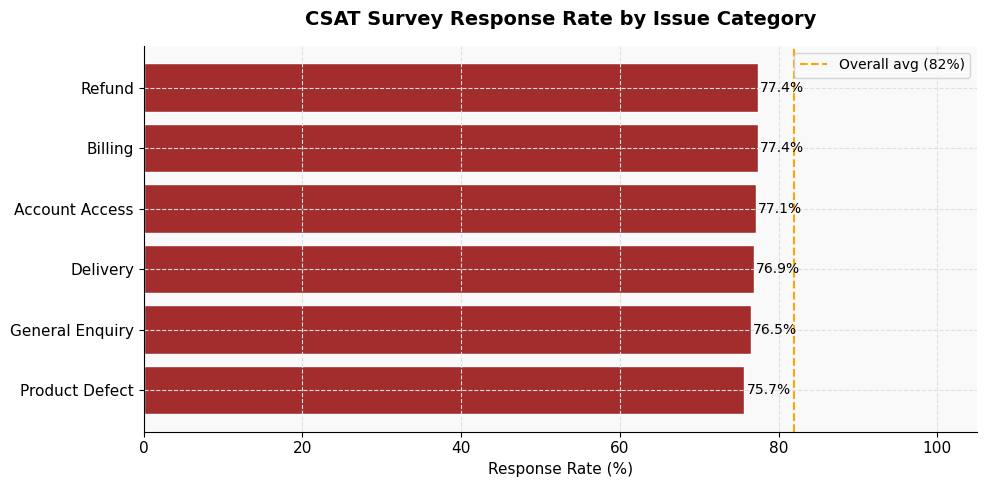

Chart saved.


In [39]:
response_by_cat = tickets.groupby("issue_category").agg(
    total_tickets  = ("ticket_id",      "count"),
    response_rate  = ("csat_responded", "mean"),
    avg_csat       = ("csat_score",     "mean")
).round(3).reset_index().sort_values("response_rate")

fig, ax = plt.subplots(figsize=(10, 5))
colors = [
    COLORS["danger"]  if r < 0.78 else
    COLORS["warning"] if r < 0.84 else
    COLORS["primary"]
    for r in response_by_cat["response_rate"]
]
bars = ax.barh(response_by_cat["issue_category"], response_by_cat["response_rate"] * 100, color=colors, edgecolor="white")
for bar, val in zip(bars, response_by_cat["response_rate"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=10)
ax.axvline(x=82, color="orange", linestyle="--", linewidth=1.5, label="Overall avg (82%)")
ax.set_title("CSAT Survey Response Rate by Issue Category", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Response Rate (%)")
ax.set_xlim(0, 105)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("data/processed/chart_10_csat_response_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [40]:
print("--- FINDING 4.4 ---")
print("Billing and Refund categories have the lowest CSAT response rates.")
print()
print("IMPLICATION:")
print("Low response rates in the highest-friction categories are not neutral.")
print("Dissatisfied customers are less likely to complete satisfaction surveys.")
print("The real satisfaction picture is likely worse than scores show.")
print()
print("RECOMMENDATION:")
print("Treat low CSAT response rate as a red flag, not a data gap.")
print()
print("RISK OF INACTION:")
print("Managing service quality using incomplete satisfaction data means")
print("the business is systematically underestimating its own problems.")

--- FINDING 4.4 ---
Billing and Refund categories have the lowest CSAT response rates.

IMPLICATION:
Low response rates in the highest-friction categories are not neutral.
Dissatisfied customers are less likely to complete satisfaction surveys.
The real satisfaction picture is likely worse than scores show.

RECOMMENDATION:
Treat low CSAT response rate as a red flag, not a data gap.

RISK OF INACTION:
Managing service quality using incomplete satisfaction data means
the business is systematically underestimating its own problems.


---
## 7. Summary

In [41]:
print("=" * 60)
print("  CUSTOMER EXPERIENCE ANALYSIS - SUMMARY")
print("=" * 60)
print()
print("FINDING 4.1 - Service failure is systemic across all segments")
print("  All three segments experience 88-90% SLA breach rates.")
print()
print("FINDING 4.2 - Resolution speed directly controls satisfaction")
print(f"  CSAT drops from {fast_csat:.2f} (same-day) to {slow_csat:.2f} (5+ days).")
print()
print("FINDING 4.3 - GBP5.7M+ CLV at active churn risk")
print(f"  {total_at_risk:,} customers flagged. {total_clv_at_risk/total_clv*100:.1f}% of portfolio CLV at risk.")
print()
print("FINDING 4.4 - CSAT non-response is itself a warning signal")
print("  Lowest response rates in Billing and Refund categories.")
print()
print("Files saved:")
print("  data/processed/customer_risk_profile.csv")
print("  data/processed/critical_risk_customers.csv")
print()
print("Next: Run Notebook 05 - Business Implications")

  CUSTOMER EXPERIENCE ANALYSIS - SUMMARY

FINDING 4.1 - Service failure is systemic across all segments
  All three segments experience 88-90% SLA breach rates.

FINDING 4.2 - Resolution speed directly controls satisfaction
  CSAT drops from 4.64 (same-day) to 1.82 (5+ days).

FINDING 4.3 - GBP5.7M+ CLV at active churn risk
  1,918 customers flagged. 33.5% of portfolio CLV at risk.

FINDING 4.4 - CSAT non-response is itself a warning signal
  Lowest response rates in Billing and Refund categories.

Files saved:
  data/processed/customer_risk_profile.csv
  data/processed/critical_risk_customers.csv

Next: Run Notebook 05 - Business Implications
